In [2]:
%load_ext autoreload
%autoreload 2
from src.core.timeseries_evaluation import get_quantile_scores, get_crps_scores, get_empirical_coverage_rates, get_crps_by_period, plot_crps, load_predictions, plot_crps_across_lead_times
import pandas as pd

/Users/louisskowronek/Documents/thesis/master-thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Evaluation Results for energy consumption

In [3]:
results = load_predictions(prediction_dirs="./results/energy_consumption/pipeline/")

2025-06-04 17:02:15,033 - INFO - timeseries_evaluation.py - Loading predictions by searching in provided directories...


2025-06-04 17:02:15,041 - INFO - timeseries_evaluation.py - Common path identified: results/energy_consumption/pipeline
2025-06-04 17:02:15,132 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/energy_consumption/pipeline/chronos-t5-finetuned-full/backtest/Chronos/predictions.joblib` as key: chronos-t5-finetuned-full_Chronos
2025-06-04 17:02:15,431 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/energy_consumption/pipeline/chronos-t5-finetuned-full/backtest/PostprocessorQR/predictions.joblib` as key: chronos-t5-finetuned-full_PostprocessorQR
2025-06-04 17:02:15,560 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/energy_consumption/pipeline/chronos-t5-finetuned-full/backtest/PostprocessorEQC/predictions.joblib` as key: chronos-t5-finetuned-full_PostprocessorEQC
2025-06-04 17:02:15,750 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/energy_consumption/pipeline/chronos-t5-finetuned-full/backtest/Postprocesso

In [4]:
crps_results = get_crps_scores(results, reference_predictions="chronos-bolt-zero-shot_Chronos")

Compute CRPS score: 100%|██████████| 36/36 [01:00<00:00,  1.68s/it]


In [10]:
crps_results

,chronos-bolt-finetuned-full_PostprocessorQR,chronos-bolt-finetuned-full_PostprocessorMLE,chronos-bolt-finetuned-full_PostprocessorEQC,chronos-bolt-finetuned-full_Chronos,chronos-bolt-finetuned-lora_PostprocessorQR,chronos-bolt-finetuned-lora_PostprocessorMLE,chronos-bolt-finetuned-lora_PostprocessorEQC,chronos-bolt-finetuned-lora_Chronos,chronos-bolt-finetuned-last-layer_PostprocessorQR,chronos-bolt-finetuned-last-layer_PostprocessorEQC,chronos-bolt-finetuned-last-layer_PostprocessorMLE,chronos-bolt-finetuned-last-layer_Chronos,chronos-bolt-zero-shot_PostprocessorQR,chronos-bolt-zero-shot_PostprocessorEQC,chronos-bolt-zero-shot_PostprocessorMLE,chronos-bolt-zero-shot_Chronos,chronos-t5-finetuned-full_PostprocessorEQC,chronos-t5-finetuned-full_PostprocessorQR,chronos-t5-finetuned-full_PostprocessorMLE,chronos-t5-finetuned-full_Chronos,chronos-t5-zero-shot_PostprocessorEQC,chronos-t5-zero-shot_PostprocessorQR,chronos-t5-zero-shot_PostprocessorMLE,chronos-t5-finetuned-lora_PostprocessorQR,chronos-t5-finetuned-lora_PostprocessorEQC,chronos-t5-finetuned-lora_PostprocessorMLE,chronos-t5-zero-shot_Chronos,chronos-t5-finetuned-lora_Chronos,seasonal_rolling_PostprocessorQR,seasonal_rolling_PostprocessorMLE,seasonal_rolling_PostprocessorEQC,seasonal_rolling_RollingSeasonalQuantilePredictor,random_walk_PostprocessorMLE,random_walk_PostprocessorQR,random_walk_PostprocessorEQC,random_walk_RandomWalkBenchmark
lead times,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.931241,0.920661,0.946699,0.964319,0.949342,0.930189,0.950170,0.971198,0.935940,0.932451,0.919543,0.943574,0.954996,0.973789,0.936356,1.0,0.751992,0.751029,0.752733,0.754815,0.794083,0.789930,0.789211,0.804560,0.809694,0.803027,0.797117,0.813544,5.370716,5.401574,5.406014,5.500648,1.937852,1.919680,1.980263,1.977449
2,0.906677,0.903984,0.914174,0.917903,0.967615,0.960570,0.965101,0.968817,0.970499,0.969159,0.964481,0.970549,0.987901,0.993688,0.983900,1.0,0.911619,0.911295,0.914953,0.923771,0.941916,0.939846,0.943804,0.950879,0.951956,0.952705,0.952022,0.965695,3.715230,3.736613,3.739692,3.805151,2.539099,2.505008,2.591517,2.650890
3,0.907116,0.906587,0.910918,0.912906,0.970508,0.966603,0.969071,0.970538,0.977347,0.975850,0.973334,0.976862,0.991953,0.996243,0.988495,1.0,0.997606,0.997676,1.000617,1.016269,1.019807,1.017429,1.019922,1.035089,1.035087,1.037382,1.039480,1.058490,2.908652,2.925391,2.927808,2.979060,2.761175,2.724228,2.859632,2.977956
4,0.910214,0.910191,0.912667,0.915603,0.967437,0.966223,0.966973,0.969954,0.977333,0.975885,0.972635,0.977822,0.991155,0.995306,0.992143,1.0,1.047933,1.048078,1.051350,1.070900,1.068707,1.064950,1.071625,1.084961,1.085101,1.085501,1.097951,1.117554,2.452980,2.467114,2.469162,2.512369,2.822010,2.794511,2.988009,3.145287
5,0.913249,0.913651,0.915474,0.919114,0.965635,0.965675,0.966609,0.971621,0.976760,0.976579,0.975969,0.979478,0.990013,0.994078,0.989794,1.0,1.078990,1.079159,1.080040,1.104940,1.100636,1.095894,1.099692,1.117343,1.117970,1.123311,1.136893,1.156139,2.172227,2.184749,2.186576,2.224830,2.804404,2.793498,3.044327,3.223560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,0.945762,0.948035,0.948839,0.953398,0.960708,0.964502,0.965915,0.968302,0.981605,0.985487,0.986651,0.987255,0.995970,0.998439,1.000115,1.0,1.141738,1.141363,1.150274,1.175101,1.148479,1.170391,1.165282,1.208701,1.220220,1.216632,1.192470,1.264377,1.119623,1.126196,1.127344,1.146959,1.864152,1.867247,2.490270,2.467695
62,0.945533,0.948023,0.948468,0.952596,0.961555,0.965322,0.966766,0.969136,0.981100,0.984919,0.986270,0.986595,0.996263,0.998554,1.000199,1.0,1.141414,1.140609,1.145014,1.175121,1.144315,1.165056,1.160089,1.202580,1.217997,1.210106,1.188833,1.263021,1.116012,1.122578,1.123693,1.143246,1.874059,1.874035,2.506622,2.484663
63,0.945343,0.947481,0.948177,0.952629,0.961795,0.965423,0.966633,0.968966,0.980830,0.984782,0.985759,0.986375,0.996481,0.998604,1.00011

In [ ]:
# make a bar chart with the mean crps results

Compute CRPS score: 100%|██████████| 3/3 [00:05<00:00,  1.89s/it]


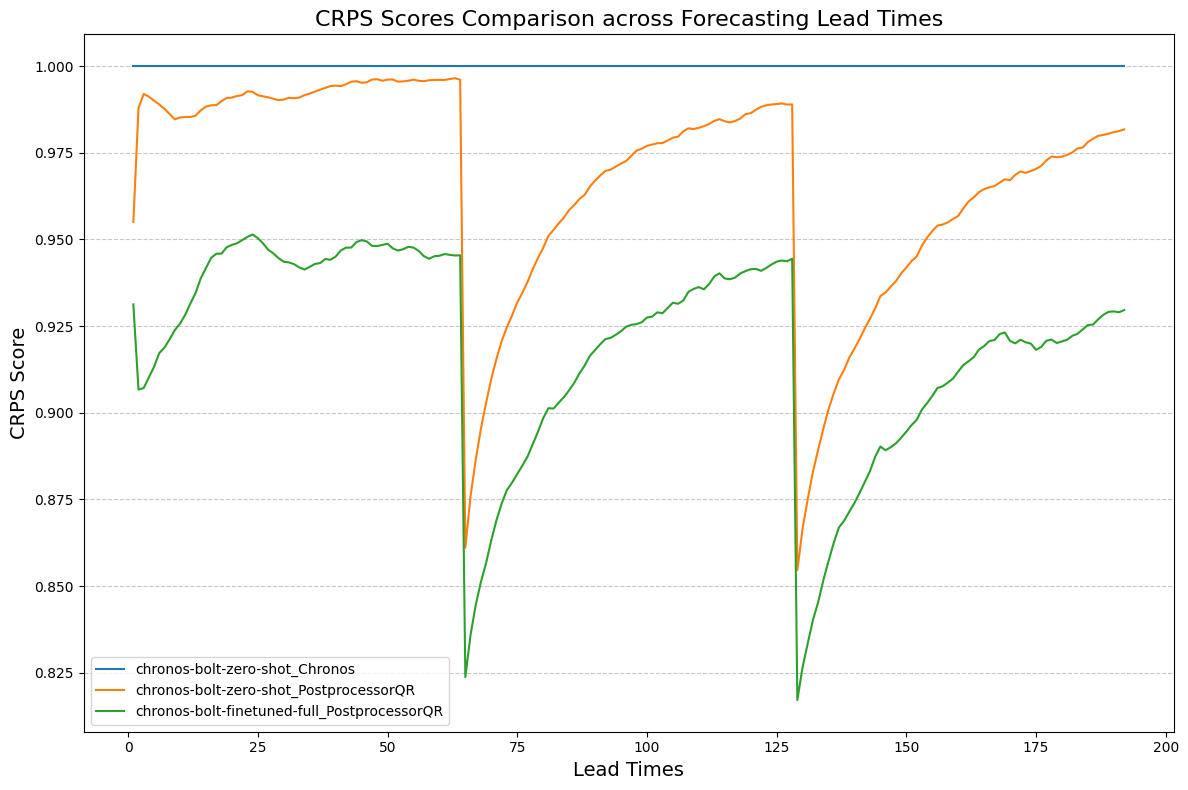

In [10]:
plot_crps_across_lead_times(results, 
                            selected_keys=["chronos-bolt-zero-shot_Chronos", 
                                            "chronos-bolt-zero-shot_PostprocessorQR",
                                            "chronos-bolt-finetuned-full_PostprocessorQR",
                                            # "seasonal_rolling_RollingSeasonalQuantilePredictor"
                                            ],
                            reference_predictions="chronos-bolt-zero-shot_Chronos")

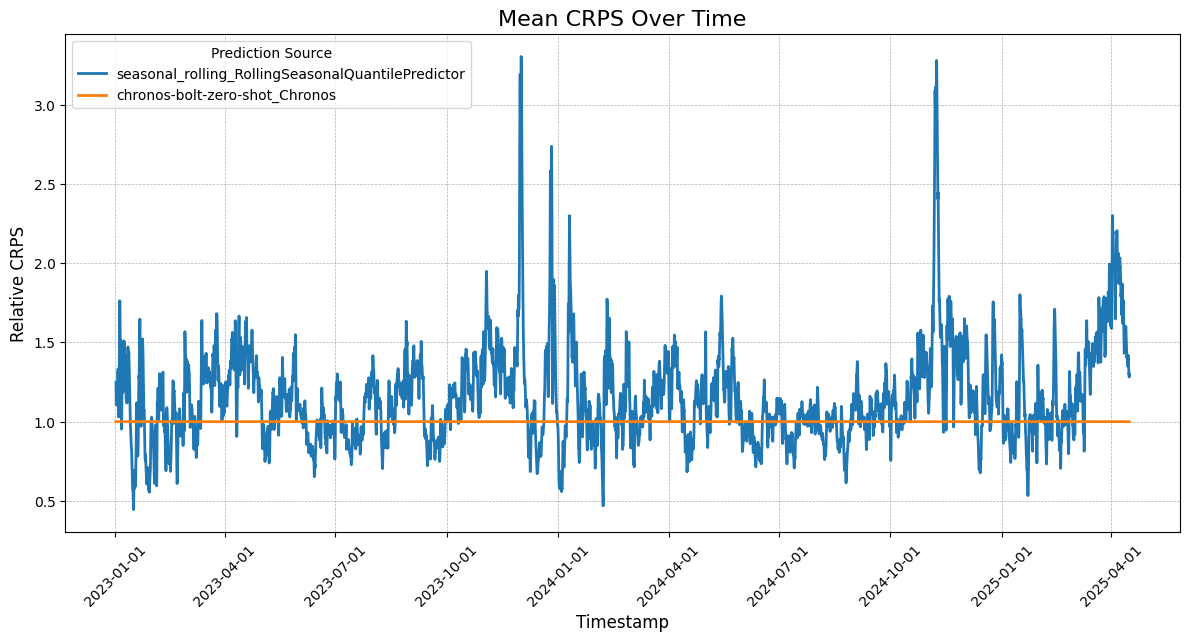

In [141]:
plot_crps(results, selected_keys = ["seasonal_rolling_RollingSeasonalQuantilePredictor",
                                    "chronos-bolt-zero-shot_Chronos"], rolling_window_eval=10, reference_predictions="chronos-bolt-zero-shot_Chronos")

In [143]:
quantile_scores = get_quantile_scores(results, reference_predictions="chronos-bolt-zero-shot_Chronos")

In [144]:
quantile_scores

,chronos-bolt-finetuned-full_PostprocessorQR,chronos-bolt-finetuned-full_PostprocessorMLE,chronos-bolt-finetuned-full_PostprocessorEQC,chronos-bolt-finetuned-lora_PostprocessorQR,chronos-bolt-finetuned-lora_PostprocessorMLE,chronos-bolt-finetuned-lora_PostprocessorEQC,chronos-bolt-finetuned-last-layer_PostprocessorQR,chronos-bolt-finetuned-last-layer_PostprocessorEQC,chronos-bolt-finetuned-last-layer_PostprocessorMLE,chronos-bolt-finetuned-full_Chronos,chronos-bolt-zero-shot_PostprocessorQR,chronos-bolt-zero-shot_PostprocessorMLE,chronos-bolt-zero-shot_PostprocessorEQC,chronos-bolt-finetuned-lora_Chronos,chronos-bolt-finetuned-last-layer_Chronos,chronos-bolt-zero-shot_Chronos,seasonal_rolling_PostprocessorQR,seasonal_rolling_PostprocessorMLE,seasonal_rolling_PostprocessorEQC,seasonal_rolling_RollingSeasonalQuantilePredictor,random_walk_PostprocessorMLE,random_walk_PostprocessorQR,random_walk_PostprocessorEQC,random_walk_RandomWalkBenchmark
quantile,,,,,,,,,,,,,,,,,,,,,,,,
0.1,0.843399,0.863556,0.857547,0.874507,0.892805,0.895646,0.873115,0.889672,0.891057,0.967621,0.894358,0.909236,0.900230,1.008480,0.987655,1.0,1.043008,1.039283,1.049435,1.140640,1.564197,1.507466,1.547110,1.616472
0.2,0.911208,0.918831,0.918580,0.936640,0.944600,0.947004,0.938654,0.945057,0.947786,0.965688,0.958183,0.965242,0.958553,0.995798,0.989341,1.0,1.108144,1.104725,1.111643,1.144001,1.700883,1.668043,1.759201,1.807057
0.3,0.939578,0.939668,0.943205,0.962746,0.964034,0.968863,0.969240,0.972202,0.971519,0.962898,0.986644,0.987724,0.986081,0.986047,0.988955,1.0,1.130622,1.126195,1.134879,1.150136,1.755158,1.737954,1.883793,1.896167
0.4,0.950068,0.946579,0.952727,0.970644,0.969042,0.975781,0.981949,0.984260,0.980581,0.959557,0.996928,0.994830,0.997474,0.978633,0.987225,1.0,1.139744,1.133343,1.148422,1.154455,1.769991,1.769375,1.983702,1.974901
0.5,0.947656,0.944737,0.950853,0.966377,0.965239,0.972247,0.981532,0.984439,0.980575,0.955781,0.995238,0.992763,0.997952,0.973268,0.984751,1.0,1.141967,1.135583,1.150980,1.152259,1.762645,1.778238,2.092402,2.097368
0.6,0.936182,0.934821,0.939971,0.954254,0.954936,0.961063,0.972135,0.975726,0.973244,0.951964,0.984993,0.984389,0.990109,0.969760,0.982728,1.0,1.136942,1.134827,1.146437,1.145558,1.740908,1.773052,2.246850,2.384314
0.7,0.916028,0.917359,0.920670,0.934255,0.937981,0.942589,0.954123,0.958208,0.958583,0.949459,0.966153,0.969484,0.974010,0.968737,0.982046,1.0,1.114404,1.124871,1.124105,1.127089,1.705455,1.746736,2.470793,2.826933
0.8,0.885189,0.891748,0.891246,0.903092,0.911585,0.914391,0.922031,0.927395,0.932325,0.950297,0.934234,0.943979,0.945633,0.971709,0.984774,1.0,1.065397,1.099935,1.076138,1.094330,1.647661,1.683861,2.812545,3.481880
0.9,0.830074,0.845377,0.839228,0.848066,0.865201,0.863647,0.862995,0.869265,0.883720,0.963059,0.877127,0.898128,0.891720,0.985239,0.998448,1.0,0.971477,1.041331,0.982024,1.057329,1.541448,1.554340,3.488439,4.508305


In [145]:
coverage_rates = get_empirical_coverage_rates(results)

In [147]:
coverage_rates

,seasonal_rolling_PostprocessorQR,seasonal_rolling_PostprocessorEQC,seasonal_rolling_PostprocessorMLE,seasonal_rolling_RollingSeasonalQuantilePredictor,chronos-bolt-finetuned-lora_Chronos,chronos-bolt-finetuned-lora_PostprocessorQR,chronos-bolt-finetuned-lora_PostprocessorEQC,chronos-bolt-finetuned-lora_PostprocessorMLE,chronos-bolt-zero-shot_Chronos,chronos-bolt-zero-shot_PostprocessorQR,chronos-bolt-zero-shot_PostprocessorEQC,chronos-bolt-zero-shot_PostprocessorMLE,random_walk_PostprocessorQR,random_walk_RandomWalkBenchmark,random_walk_PostprocessorEQC,random_walk_PostprocessorMLE,chronos-bolt-finetuned-full_Chronos,chronos-bolt-finetuned-full_PostprocessorQR,chronos-bolt-finetuned-full_PostprocessorEQC,chronos-bolt-finetuned-full_PostprocessorMLE,chronos-bolt-finetuned-last-layer_Chronos,chronos-bolt-finetuned-last-layer_PostprocessorQR,chronos-bolt-finetuned-last-layer_PostprocessorEQC,chronos-bolt-finetuned-last-layer_PostprocessorMLE
quantile,,,,,,,,,,,,,,,,,,,,,,,,
0.1,0.134550,0.108982,0.120705,0.197802,0.161966,0.115014,0.097552,0.103241,0.156057,0.120150,0.105090,0.103307,0.213804,0.067320,0.158415,0.228009,0.154012,0.114461,0.098097,0.101367,0.168958,0.114117,0.094259,0.099072
0.2,0.242621,0.211211,0.213110,0.289304,0.256242,0.220228,0.198120,0.184743,0.249018,0.232136,0.211608,0.187842,0.346903,0.128508,0.254894,0.368795,0.240011,0.214671,0.196469,0.181823,0.269523,0.217848,0.194385,0.180273
0.3,0.348196,0.318426,0.311971,0.377985,0.335140,0.323358,0.302054,0.277247,0.327988,0.336675,0.313639,0.282447,0.454451,0.221389,0.340431,0.474063,0.313605,0.316548,0.297289,0.273777,0.349285,0.322025,0.300253,0.274719
0.4,0.452578,0.418981,0.428099,0.456037,0.406821,0.421316,0.403205,0.381811,0.400665,0.433885,0.410779,0.388373,0.552492,0.343204,0.421093,0.563576,0.382179,0.414490,0.398416,0.377534,0.420717,0.422184,0.403072,0.381682
0.5,0.552896,0.521355,0.542768,0.530814,0.477093,0.515608,0.500637,0.495019,0.472514,0.527141,0.504419,0.503219,0.651182,0.502237,0.499980,0.649879,0.448011,0.507294,0.494195,0.488929,0.488927,0.518101,0.501869,0.496738
0.6,0.644238,0.622119,0.646381,0.602628,0.548910,0.610053,0.596562,0.612831,0.546907,0.618851,0.597276,0.621603,0.747237,0.662412,0.578421,0.734815,0.515751,0.600161,0.589267,0.603850,0.557521,0.612340,0.599783,0.613477
0.7,0.730513,0.711672,0.743319,0.668477,0.623850,0.704480,0.692095,0.727648,0.626496,0.709590,0.690012,0.734917,0.828453,0.784987,0.659852,0.814852,0.588067,0.694994,0.685205,0.720034,0.629617,0.705288,0.694903,0.726829
0.8,0.816230,0.802339,0.831681,0.735794,0.707568,0.799896,0.788539,0.834592,0.716247,0.801512,0.784423,0.839533,0.897952,0.876672,0.746321,0.887839,0.670919,0.791701,0.783868,0.830074,0.708596,0.799373,0.790051,0.832322
0.9,0.907906,0.897829,0.921765,0.801551,0.810537,0.899807,0.891299,0.928772,0.827686,0.900040,0.887213,0.931727,0.957314,0.936379,0.843523,0.954979,0.776620,0.893369,0.888301,0.925672,0.805610,0.899641,0.892842,0.927506


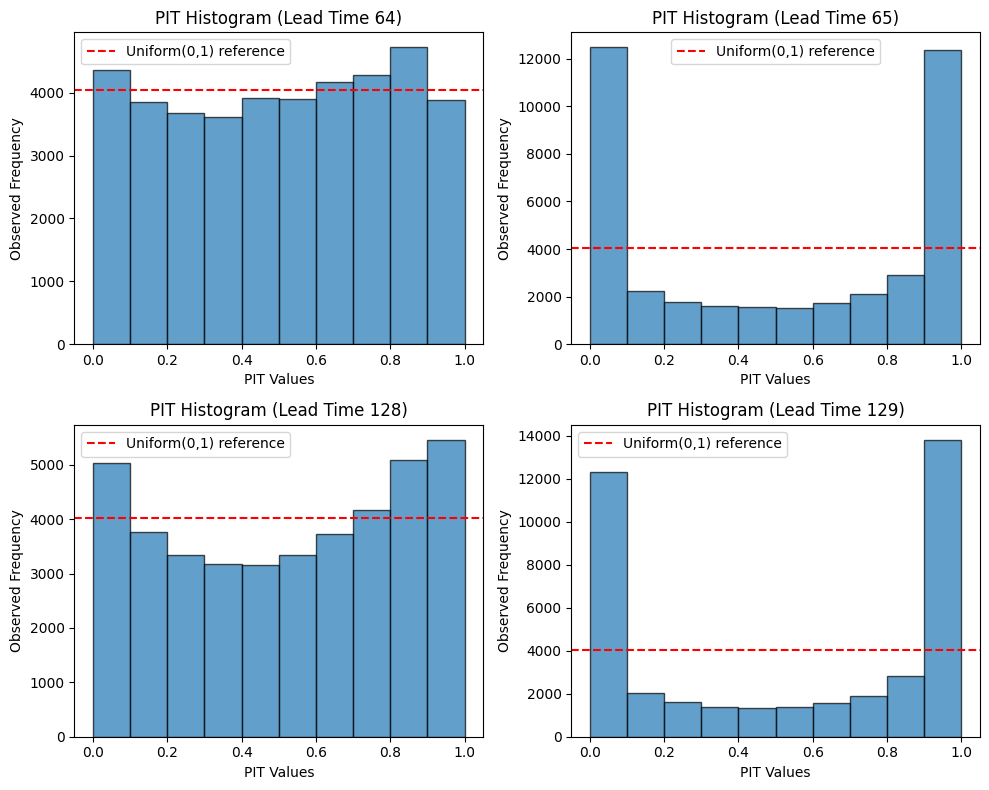

In [148]:
results["chronos-bolt-zero-shot_Chronos"].get_pit_histogram(overlay=False, lead_times=[64,65,128,129])

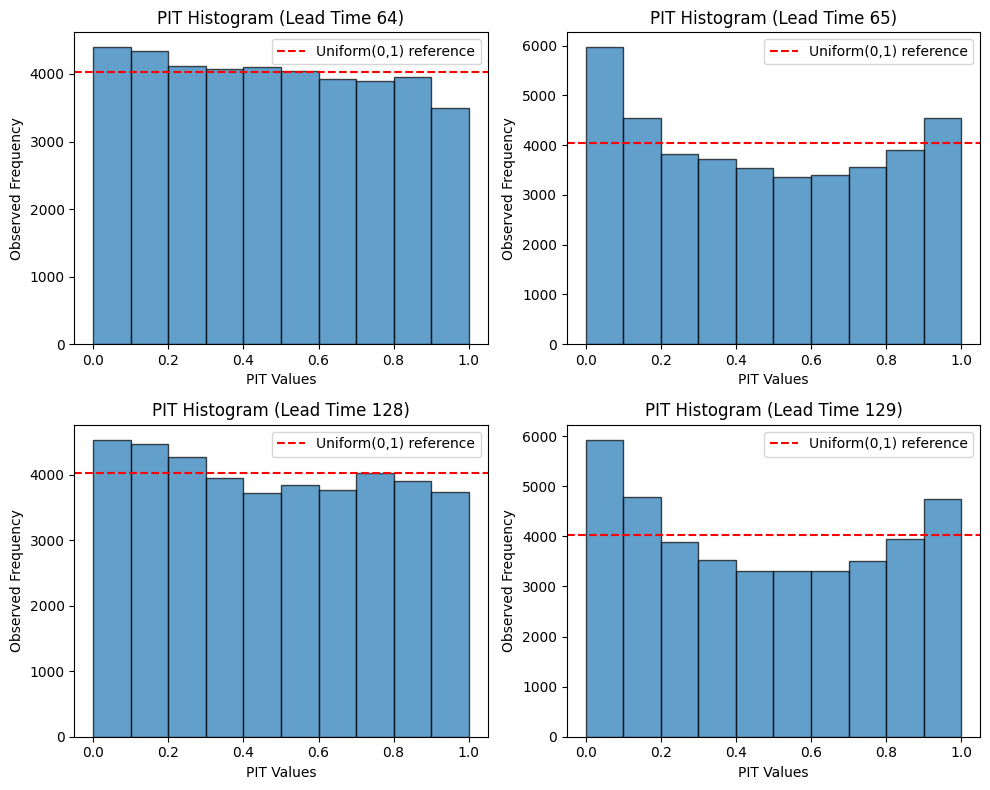

In [149]:
results["chronos-bolt-zero-shot_PostprocessorQR"].get_pit_histogram(overlay=False, lead_times=[64,65,128,129])

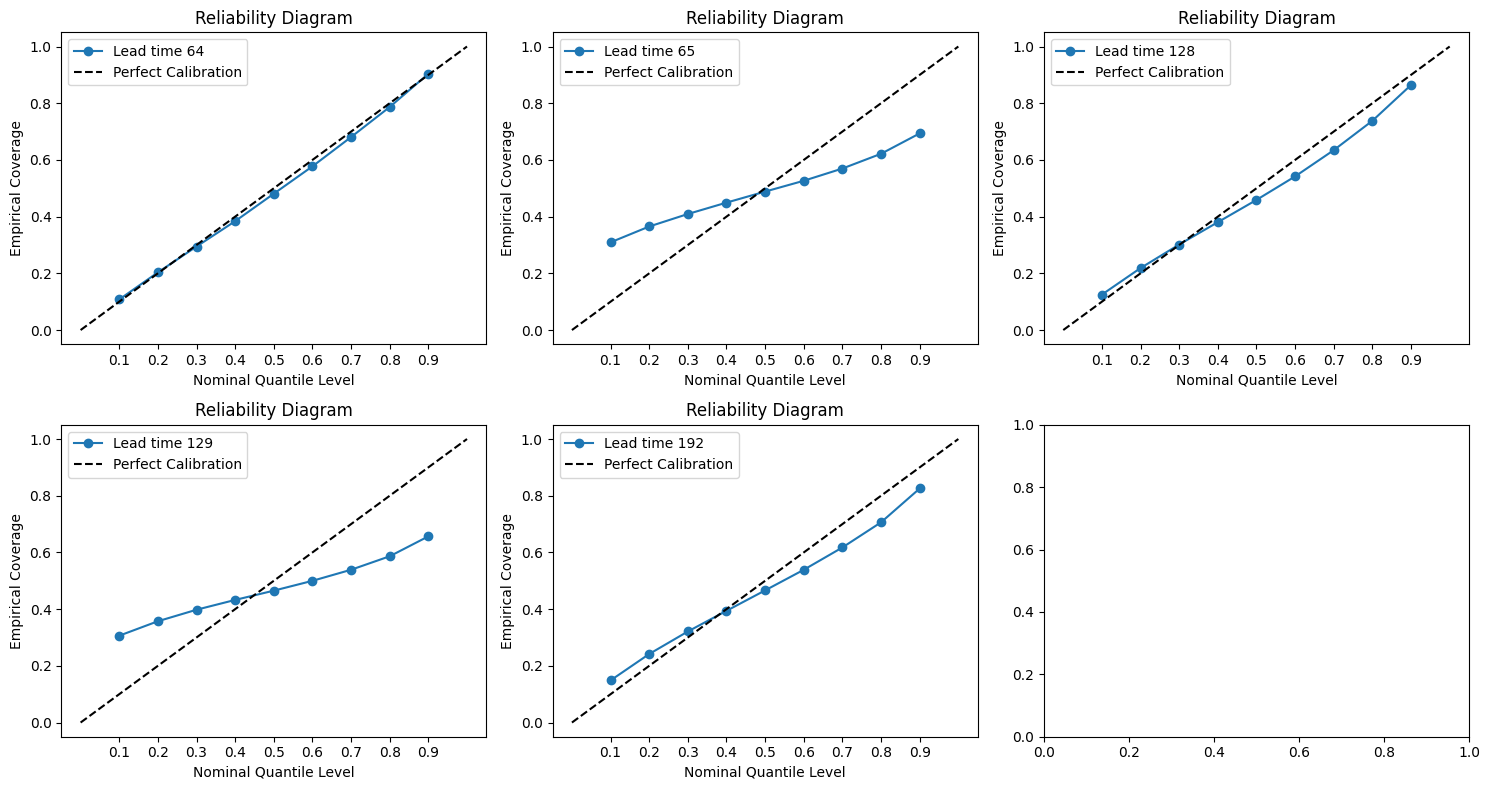

In [150]:
results["chronos-bolt-zero-shot_Chronos"].get_reliability_diagram(overlay=False, lead_times=[64,65,128,129,192])

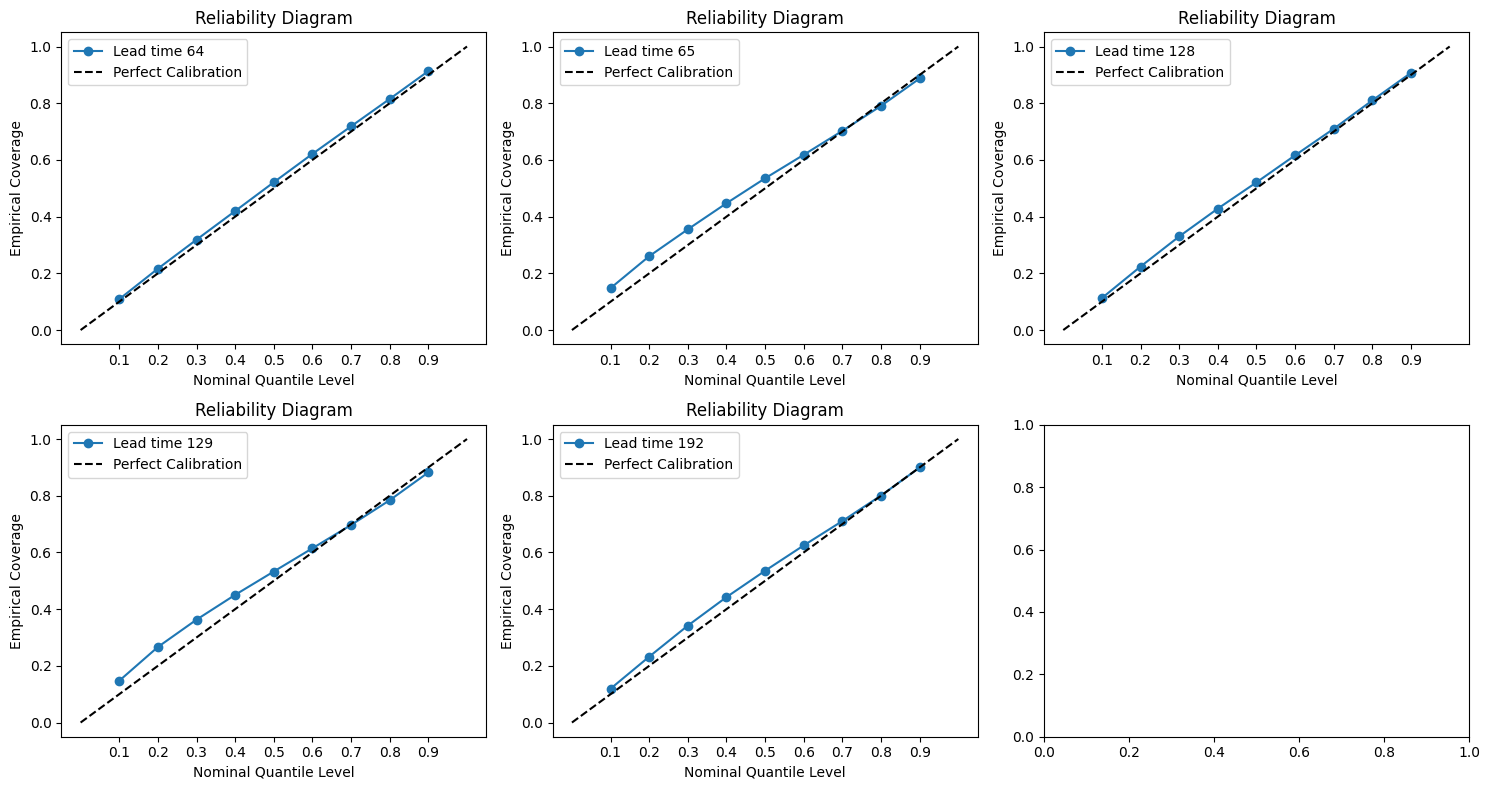

In [151]:
results["chronos-bolt-zero-shot_PostprocessorQR"].get_reliability_diagram(overlay=False, lead_times=[64,65,128,129,192])

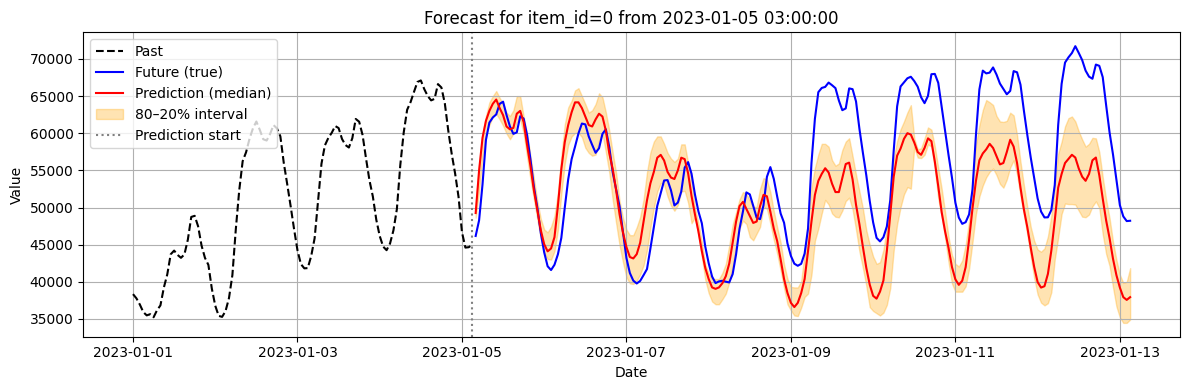

In [11]:
results["chronos-t5-zero-shot_Chronos"].item_ids[0].plot_forecasts(start=100)

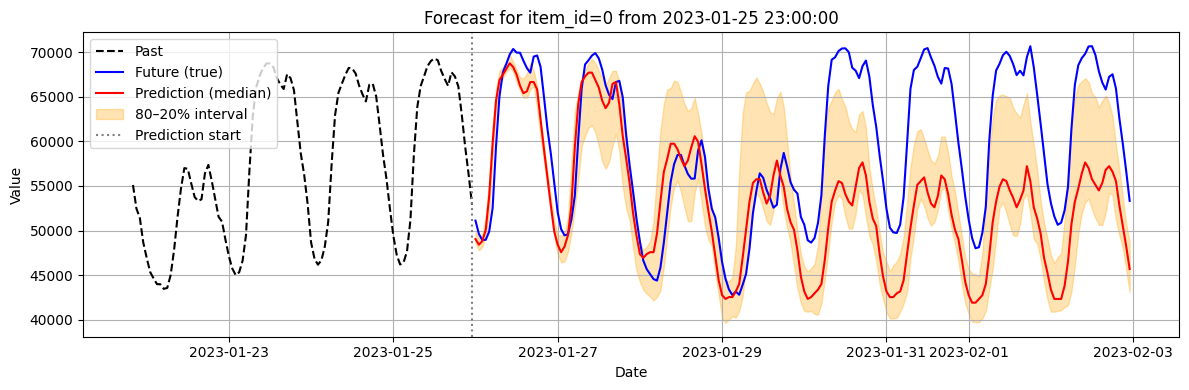

In [13]:
results["chronos-t5-finetuned-full_Chronos"].item_ids[0].plot_forecasts(start=600)

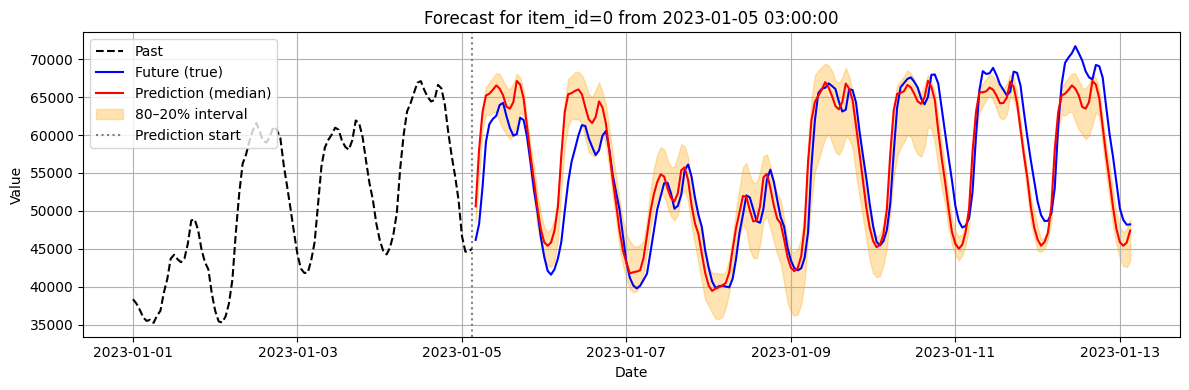

In [152]:
results["seasonal_rolling_RollingSeasonalQuantilePredictor"].item_ids[0].plot_forecasts(start=100)

# Evaluation Wholesale Prices

In [153]:
results = load_predictions(prediction_dirs="./results/wholesale_prices/pipeline/", load=False)

2025-05-31 13:53:53,541 - INFO - <string> - Loading predictions by searching in provided directories...
2025-05-31 13:53:53,555 - INFO - <string> - Common path identified: results/wholesale_prices/pipeline
2025-05-31 13:53:53,556 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/seasonal_rolling/backtest/PostprocessorQR/predictions.joblib` as key: seasonal_rolling_PostprocessorQR
2025-05-31 13:53:53,556 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/seasonal_rolling/backtest/PostprocessorEQC/predictions.joblib` as key: seasonal_rolling_PostprocessorEQC
2025-05-31 13:53:53,557 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/seasonal_rolling/backtest/PostprocessorMLE/predictions.joblib` as key: seasonal_rolling_PostprocessorMLE
2025-05-31 13:53:53,557 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/seasonal_rolling/backtest/RollingSeasonalQuantilePredictor/predictions.jo

2025-05-31 13:53:53,560 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/chronos-bolt-finetuned-lora/backtest/PostprocessorMLE/predictions.joblib` as key: chronos-bolt-finetuned-lora_PostprocessorMLE
2025-05-31 13:53:53,560 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/chronos-bolt-zero-shot/backtest/Chronos/predictions.joblib` as key: chronos-bolt-zero-shot_Chronos
2025-05-31 13:53:53,561 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/chronos-bolt-zero-shot/backtest/PostprocessorQR/predictions.joblib` as key: chronos-bolt-zero-shot_PostprocessorQR
2025-05-31 13:53:53,561 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/chronos-bolt-zero-shot/backtest/PostprocessorEQC/predictions.joblib` as key: chronos-bolt-zero-shot_PostprocessorEQC
2025-05-31 13:53:53,562 - INFO - <string> - Found prediction file: `results/wholesale_prices/pipeline/chronos-bolt-zero-shot/backtest/

In [ ]:
# TODO: 
# lazy loading when calculating the metrics. only provide a file directory instead of the loaded predictions
# train chronos with autogluon and check perfomance -- done
# use all remaining data which was not used for training for calibration.

In [154]:
crps_results = get_crps_scores(results, reference_predictions="chronos-bolt-zero-shot_Chronos")

<string>:19: RuntimeWarning: Mean of empty slice.
/Users/louisskowronek/Documents/thesis/master-thesis/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
<string>:19: RuntimeWarning: Mean of empty slice.
/Users/louisskowronek/Documents/thesis/master-thesis/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
<string>:19: RuntimeWarning: Mean of empty slice.
/Users/louisskowronek/Documents/thesis/master-thesis/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
<string>:19: RuntimeWarning: Mean of empty slice.
/Users/louisskowronek/Documents/thesis/master-thesis/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in sca

In [155]:
crps_results

,chronos-bolt-finetuned-full_PostprocessorEQC,chronos-bolt-finetuned-full_PostprocessorQR,chronos-bolt-finetuned-lora_PostprocessorEQC,chronos-bolt-finetuned-lora_PostprocessorQR,chronos-bolt-finetuned-last-layer_PostprocessorEQC,chronos-bolt-finetuned-last-layer_PostprocessorQR,chronos-bolt-finetuned-lora_PostprocessorMLE,chronos-bolt-finetuned-full_PostprocessorMLE,chronos-bolt-zero-shot_PostprocessorQR,chronos-bolt-finetuned-full_Chronos,chronos-bolt-zero-shot_PostprocessorMLE,chronos-bolt-finetuned-lora_Chronos,chronos-bolt-finetuned-last-layer_PostprocessorMLE,chronos-bolt-zero-shot_PostprocessorEQC,chronos-bolt-finetuned-last-layer_Chronos,chronos-bolt-zero-shot_Chronos,seasonal_rolling_PostprocessorEQC,seasonal_rolling_RollingSeasonalQuantilePredictor,seasonal_rolling_PostprocessorQR,seasonal_rolling_PostprocessorMLE,random_walk_PostprocessorQR,random_walk_PostprocessorMLE,random_walk_PostprocessorEQC,random_walk_RandomWalkBenchmark
lead times,,,,,,,,,,,,,,,,,,,,,,,,
1,0.943015,0.942447,0.962537,0.958388,0.964448,0.962131,0.966692,0.954482,0.986388,0.945352,0.996338,0.964493,0.969380,0.997681,0.965601,1.0,3.568153,3.578673,3.667248,3.889773,1.317235,1.320801,1.325784,1.330291
2,0.948271,0.947078,0.967404,0.964784,0.978099,0.975782,0.972718,0.956743,0.993553,0.949064,1.003399,0.967746,0.983601,0.999867,0.978174,1.0,2.632596,2.640357,2.705715,2.870040,1.694258,1.703824,1.727006,1.728979
3,0.952213,0.950796,0.967586,0.965148,0.981102,0.979181,0.973975,0.960308,0.994173,0.953151,1.002674,0.967908,0.986807,0.999518,0.981454,1.0,2.244641,2.251260,2.306995,2.447261,1.912080,1.927786,1.975828,1.983627
4,0.956407,0.955193,0.967722,0.965568,0.983612,0.981952,0.975116,0.965864,0.994135,0.957494,1.001305,0.968248,0.989949,0.999046,0.984402,1.0,2.034473,2.040468,2.091005,2.218287,2.031546,2.053686,2.121801,2.133425
5,0.958758,0.958002,0.968017,0.966231,0.983692,0.982245,0.975717,0.969461,0.994482,0.960220,1.001017,0.968923,0.989863,0.998400,0.984978,1.0,1.899422,1.905018,1.952208,2.071199,2.079837,2.097661,2.188809,2.199906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,0.942896,0.954897,0.950937,0.958452,0.957418,0.964830,0.975066,0.981234,0.966282,0.979217,0.975427,0.984612,0.983331,0.975226,0.988939,1.0,1.064880,1.068979,1.095777,1.184326,1.285199,1.296237,2.280583,2.900605
190,0.945286,0.957234,0.953389,0.961028,0.959174,0.966628,0.977417,0.983555,0.967286,0.980609,0.976401,0.986103,0.985138,0.975734,0.990440,1.0,1.067118,1.071225,1.098096,1.186831,1.197919,1.203932,2.223381,2.871769
191,0.945639,0.957549,0.954907,0.962366,0.959637,0.967018,0.980274,0.988879,0.967773,0.980419,0.977887,0.987143,0.987657,0.975885,0.991263,1.0,1.068096,1.072205,1.099132,1.187956,1.113672,1.118747,2.174706,2.847488


Compute CRPS score:: 100%|██████████| 4/4 [00:54<00:00, 13.71s/it]


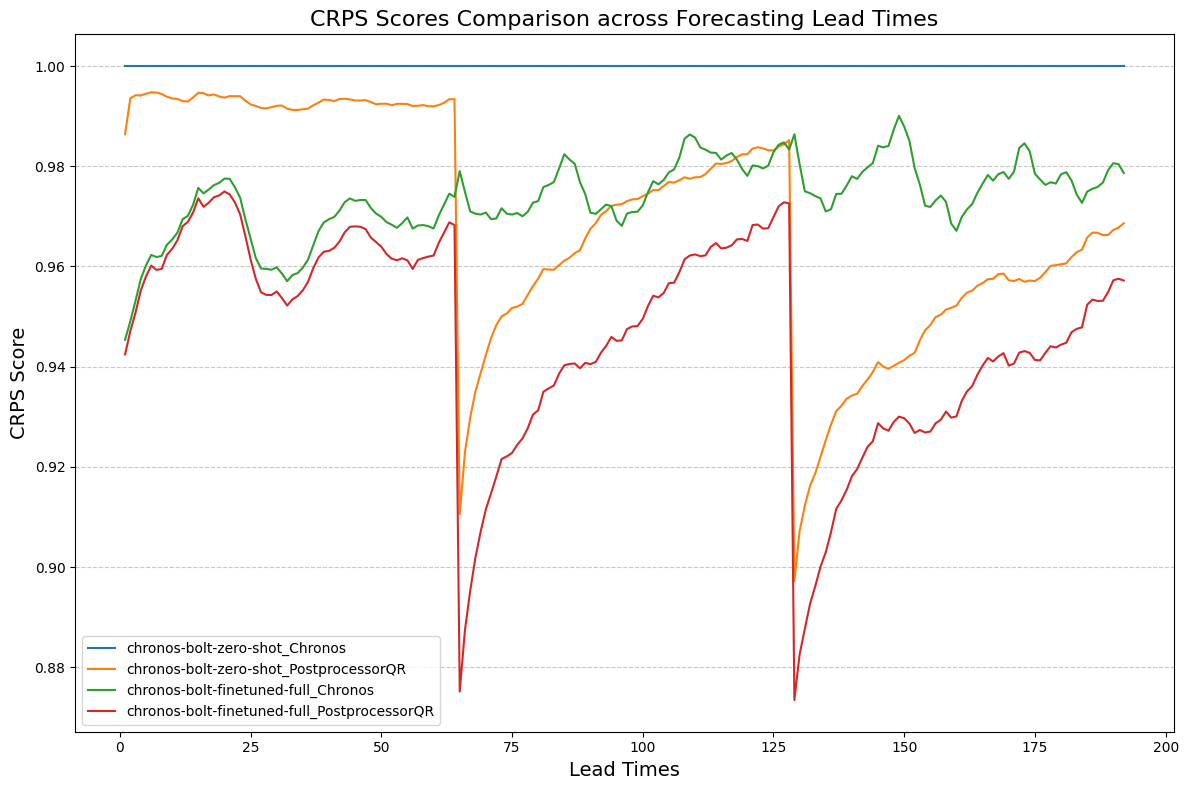

In [157]:
plot_crps_across_lead_times(results, 
                            selected_keys=["chronos-bolt-zero-shot_Chronos", 
                                            "chronos-bolt-zero-shot_PostprocessorQR",
                                            "chronos-bolt-finetuned-full_Chronos",
                                            "chronos-bolt-finetuned-full_PostprocessorQR",
                                            ],
                            reference_predictions="chronos-bolt-zero-shot_Chronos")

In [ ]:
results["seasonal_rolling_RollingSeasonalQuantilePredictor"].item_ids[0].plot_forecasts(start=100)

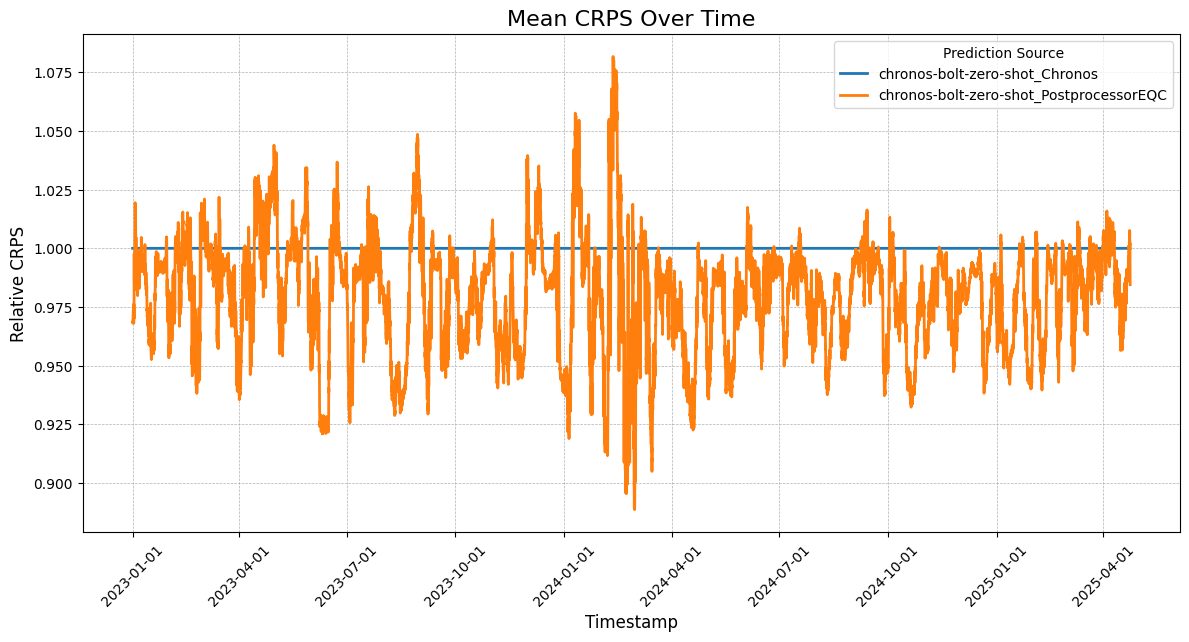

In [54]:
# update offset not only once on a calibration dataset but continously update it
plot_crps(predictions=results, selected_keys=["chronos-bolt-zero-shot_PostprocessorEQC", "chronos-bolt-zero-shot_Chronos"], reference_predictions="chronos-bolt-zero-shot_Chronos")

# Evaluation Exchange Rates

In [4]:
results = load_predictions(prediction_dirs="./results/exchange_rates/pipeline/", load=True)

2025-06-11 14:31:06,101 - INFO - timeseries_evaluation.py - Loading predictions by searching in provided directories...


2025-06-11 14:31:06,113 - INFO - timeseries_evaluation.py - Common path identified: results/exchange_rates/pipeline
2025-06-11 14:31:06,176 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/exchange_rates/pipeline/chronos-t5-zero-shot_prediction_length_192/backtest/Chronos/predictions.joblib` as key: chronos-t5-zero-shot_prediction_length_192_Chronos
2025-06-11 14:31:06,253 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/exchange_rates/pipeline/chronos-t5-zero-shot_prediction_length_192/backtest/PostprocessorQR/predictions.joblib` as key: chronos-t5-zero-shot_prediction_length_192_PostprocessorQR
2025-06-11 14:31:06,313 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/exchange_rates/pipeline/chronos-t5-zero-shot_prediction_length_192/backtest/PostprocessorEQC/predictions.joblib` as key: chronos-t5-zero-shot_prediction_length_192_PostprocessorEQC
2025-06-11 14:31:06,382 - INFO - timeseries_evaluation.py - Loaded prediction file

In [ ]:
from sklearn import metrics

In [30]:
f = results["chronos-bolt-finetuned-last-layer_Chronos"].item_ids[0].to_dataframe(1)

In [37]:
for i in range(1,193):
    f = results["chronos-bolt-zero-shot_Chronos"].item_ids[1].to_dataframe(i)
    y_pred = f["current"]<f[0.5]
    y_true = f["current"]<f["target"]
    print(f"{i}: ", metrics.accuracy_score(y_true, y_pred))

1:  0.5239669421487604
2:  0.5190082644628099
3:  0.5421487603305785
4:  0.5487603305785124
5:  0.543801652892562
6:  0.5553719008264463
7:  0.5652892561983471
8:  0.5322314049586777
9:  0.5322314049586777
10:  0.5603305785123966
11:  0.5454545454545454
12:  0.5206611570247934
13:  0.5338842975206611
14:  0.5537190082644629
15:  0.5553719008264463
16:  0.5537190082644629
17:  0.509090909090909
18:  0.5289256198347108
19:  0.5305785123966942
20:  0.5355371900826447
21:  0.5371900826446281
22:  0.5239669421487604
23:  0.515702479338843
24:  0.5173553719008265
25:  0.5190082644628099
26:  0.48760330578512395
27:  0.4743801652892562
28:  0.47107438016528924
29:  0.4793388429752066
30:  0.5223140495867769
31:  0.5140495867768595
32:  0.4743801652892562
33:  0.47768595041322315
34:  0.5074380165289256
35:  0.512396694214876
36:  0.48760330578512395
37:  0.4809917355371901
38:  0.4743801652892562
39:  0.46611570247933887
40:  0.4677685950413223
41:  0.4677685950413223
42:  0.47107438016528924

0.5008264462809917

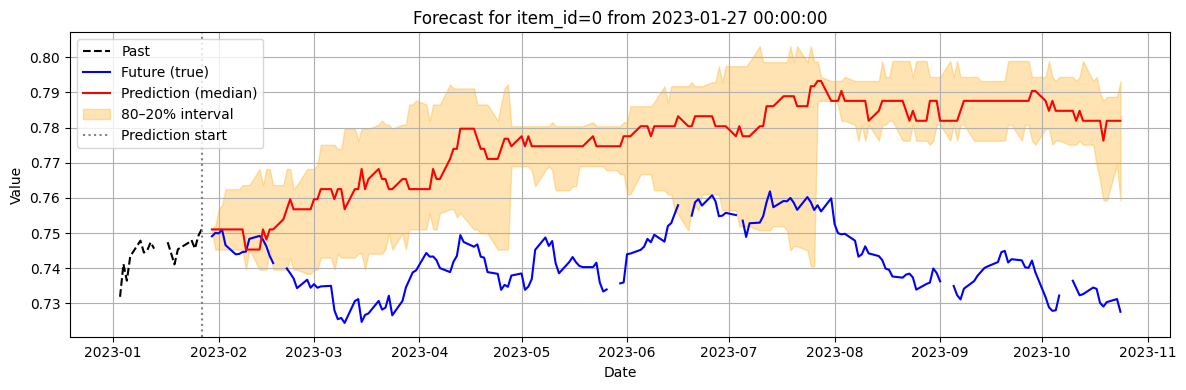

In [35]:
results["chronos-t5-zero-shot_Chronos"].item_ids[0].plot_forecasts(20)

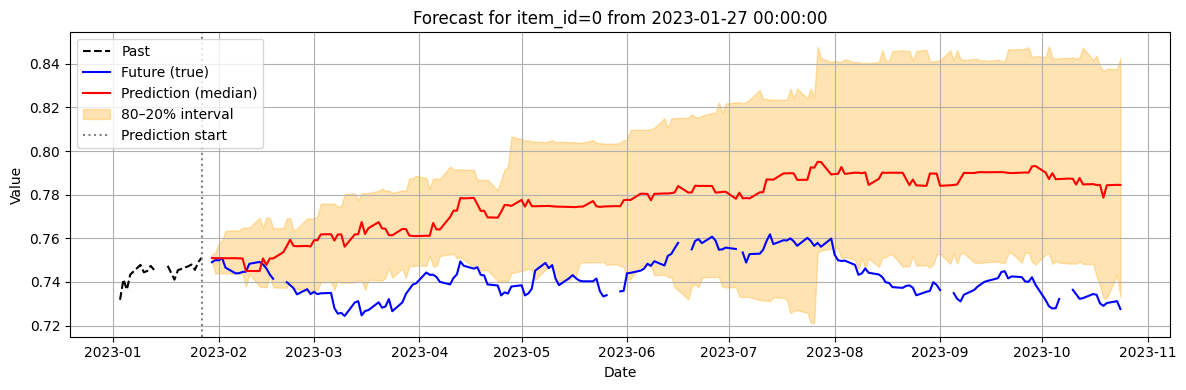

In [ ]:
results["chronos-t5-zero-shot_PostprocessorEQC"].item_ids[0].plot_forecasts(20)

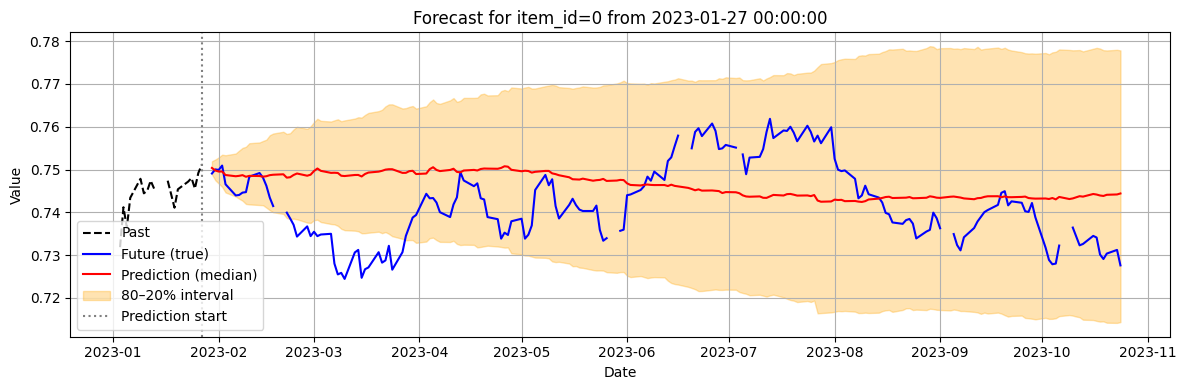

In [36]:
results["chronos-bolt-zero-shot_PostprocessorEQC"].item_ids[0].plot_forecasts(20)

In [160]:
get_empirical_coverage_rates(results)

,seasonal_rolling_PostprocessorQR,seasonal_rolling_PostprocessorEQC,seasonal_rolling_PostprocessorMLE,seasonal_rolling_RollingSeasonalQuantilePredictor,chronos-bolt-finetuned-lora_Chronos,chronos-bolt-finetuned-lora_PostprocessorQR,chronos-bolt-finetuned-lora_PostprocessorEQC,chronos-bolt-finetuned-lora_PostprocessorMLE,chronos-bolt-zero-shot_Chronos,chronos-bolt-zero-shot_PostprocessorQR,chronos-bolt-zero-shot_PostprocessorEQC,chronos-bolt-zero-shot_PostprocessorMLE,random_walk_PostprocessorQR,random_walk_RandomWalkBenchmark,random_walk_PostprocessorEQC,random_walk_PostprocessorMLE,chronos-bolt-finetuned-full_Chronos,chronos-bolt-finetuned-full_PostprocessorQR,chronos-bolt-finetuned-full_PostprocessorEQC,chronos-bolt-finetuned-full_PostprocessorMLE,chronos-bolt-finetuned-last-layer_Chronos,chronos-bolt-finetuned-last-layer_PostprocessorQR,chronos-bolt-finetuned-last-layer_PostprocessorEQC,chronos-bolt-finetuned-last-layer_PostprocessorMLE
quantile,,,,,,,,,,,,,,,,,,,,,,,,
0.1,0.117903,0.037968,0.056119,0.389217,0.295127,0.080866,0.032427,0.155984,0.327454,0.133474,0.057805,0.077825,0.126995,0.029570,0.076053,0.068696,0.310660,0.097040,0.037547,0.179689,0.274784,0.081039,0.022289,0.186230
0.2,0.232995,0.161053,0.167218,0.437823,0.384724,0.166033,0.076481,0.231847,0.418448,0.252795,0.154864,0.192848,0.250614,0.121703,0.209829,0.184735,0.399195,0.186122,0.080611,0.260936,0.372312,0.176644,0.066703,0.271700
0.3,0.346622,0.303505,0.300544,0.481201,0.452968,0.285977,0.134942,0.301836,0.484672,0.360410,0.270234,0.318109,0.374085,0.244341,0.329491,0.313097,0.461528,0.312013,0.133730,0.337356,0.443879,0.313103,0.131464,0.346001
0.4,0.467441,0.423633,0.450934,0.523624,0.515118,0.379552,0.207883,0.371165,0.541296,0.468759,0.398277,0.445307,0.491643,0.389332,0.449925,0.461556,0.515164,0.425860,0.203585,0.410111,0.506711,0.408060,0.210421,0.419677
0.5,0.598344,0.572567,0.624617,0.565757,0.571203,0.477791,0.293562,0.442213,0.592992,0.583723,0.527422,0.587120,0.608735,0.568794,0.576236,0.622423,0.566633,0.511232,0.291301,0.487054,0.565461,0.514797,0.313439,0.493916
0.6,0.732719,0.713784,0.777622,0.608066,0.622810,0.582959,0.392795,0.522683,0.641085,0.701213,0.658444,0.728569,0.721427,0.735062,0.699221,0.759469,0.618338,0.601120,0.398290,0.566752,0.619969,0.617620,0.435989,0.567009
0.7,0.837219,0.840823,0.870140,0.648218,0.674184,0.690936,0.507796,0.608598,0.689604,0.801050,0.786947,0.824517,0.823523,0.861758,0.816892,0.859062,0.669733,0.692335,0.550895,0.643118,0.673447,0.702318,0.568892,0.639874
0.8,0.910333,0.921989,0.930596,0.689836,0.731270,0.766322,0.680299,0.697964,0.742812,0.877970,0.881783,0.899205,0.897862,0.938315,0.901623,0.930669,0.725104,0.764215,0.714213,0.721117,0.729484,0.768566,0.750043,0.712835
0.9,0.963327,0.969700,0.972654,0.733524,0.805772,0.830120,0.863644,0.793811,0.812466,0.941745,0.947817,0.952578,0.958537,0.981442,0.962531,0.976206,0.792074,0.833670,0.854199,0.803069,0.796101,0.830984,0.893064,0.797154


In [37]:
get_crps_scores(results, reference_predictions="chronos-bolt-zero-shot_Chronos")

Compute CRPS score: 100%|██████████| 32/32 [01:13<00:00,  2.30s/it]


,random_walk_PostprocessorQR,random_walk_PostprocessorEQC,chronos-bolt-finetuned-last-layer_Chronos,chronos-bolt-finetuned-lora_Chronos,chronos-bolt-zero-shot_PostprocessorEQC,chronos-bolt-zero-shot_Chronos,random_walk_PostprocessorMLE,chronos-bolt-finetuned-full_Chronos,random_walk_RandomWalkBenchmark,seasonal_rolling_PostprocessorQR,seasonal_rolling_RollingSeasonalQuantilePredictor,chronos-bolt-zero-shot_PostprocessorQR,seasonal_rolling_PostprocessorEQC,chronos-bolt-zero-shot_PostprocessorMLE,seasonal_rolling_PostprocessorMLE,chronos-bolt-finetuned-last-layer_PostprocessorEQC,chronos-bolt-finetuned-lora_PostprocessorEQC,chronos-t5-zero-shot_PostprocessorEQC,chronos-bolt-finetuned-lora_PostprocessorMLE,chronos-bolt-finetuned-full_PostprocessorMLE,chronos-bolt-finetuned-full_PostprocessorEQC,chronos-t5-zero-shot_Chronos,chronos-bolt-finetuned-lora_PostprocessorQR,chronos-bolt-finetuned-last-layer_PostprocessorMLE,chronos-t5-zero-shot_PostprocessorQR,chronos-bolt-finetuned-full_PostprocessorQR,chronos-t5-zero-shot_PostprocessorMLE,chronos-bolt-finetuned-last-layer_PostprocessorQR,chronos-t5-zero-shot_prediction_length_192_PostprocessorMLE,chronos-t5-zero-shot_prediction_length_192_PostprocessorEQC,chronos-t5-zero-shot_prediction_length_192_PostprocessorQR,chronos-t5-zero-shot_prediction_length_192_Chronos
lead times,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.844141,0.847761,0.985838,1.007195,1.010691,1.0,0.867878,1.069737,0.867748,3.240792,3.381321,1.027622,3.252620,0.993178,3.295071,0.994918,1.017383,1.069753,0.979324,1.050205,1.078582,1.104270,0.985730,0.984579,1.069576,1.057061,1.025939,0.991268,1.017347,1.069753,1.068658,1.101396
2,0.917863,0.921189,1.000529,1.017537,1.008458,1.0,0.939813,1.057770,0.940518,2.509086,2.619203,1.017499,2.518020,0.999284,2.550284,1.009844,1.025838,1.090274,1.012039,1.047118,1.064082,1.096871,1.020247,1.009485,1.092613,1.056252,1.068231,1.016708,1.071579,1.098640,1.099315,1.105548
3,0.934100,0.937297,1.003168,1.022582,1.005756,1.0,0.957631,1.055201,0.960273,2.160958,2.256290,1.016070,2.168509,1.002869,2.196496,1.012859,1.031107,1.095460,1.022670,1.050186,1.061926,1.097168,1.027962,1.018427,1.098610,1.056597,1.088696,1.018336,1.097030,1.105717,1.107917,1.108225
4,0.944498,0.948458,1.003579,1.024185,1.003608,1.0,0.967752,1.056871,0.971024,1.923386,2.009317,1.015822,1.929961,1.003296,1.956273,1.013459,1.033407,1.096216,1.027513,1.052784,1.064343,1.097453,1.034488,1.020433,1.100720,1.066340,1.094289,1.024598,1.103360,1.102397,1.105119,1.104391
5,0.951814,0.955782,1.004331,1.021670,1.003941,1.0,0.973152,1.055037,0.976418,1.729611,1.807242,1.014942,1.735376,1.003530,1.757754,1.014287,1.032045,1.095485,1.030601,1.051796,1.063863,1.098562,1.039586,1.025074,1.100548,1.063021,1.098014,1.025554,1.091952,1.094900,1.098973,1.096873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,0.983353,0.982255,0.905265,0.926997,1.037799,1.0,1.099873,0.904253,1.084939,1.016701,0.954280,1.142895,1.030805,1.327334,1.188507,1.607200,1.707190,1.530637,1.480782,1.648498,1.809967,1.560657,1.904580,1.864782,1.874844,1.959433,1.977150,2.074546,3.459577,2.604117,3.018045,2.857680
190,0.979759,0.977882,0.904071,0.927354,1.035862,1.0,1.120516,0.902181,1.080253,1.010826,0.950011,1.141177,1.024516,1.149360,1.180579,1.618903,1.715369,1.525925,1.473133,1.649440,1.819407,1.552863,1.904834,1.851917,1.864877,1.975870,1.923884,2.058302,2.719502,2.600417,3.019597,2.856484
191,0.980969,0.980298,0.904628,0.930420,1.035799,1.0,1.122787,0.902740,1.081835,1.029109,0.970958,1.142062,1.042933,1.139123,1.154336,1.625504,1.735499,1.523897,1.471861,1.658189,1.834439,1.549858,1.891666,1.862358,1.868671,1.987016,2.136135,2.083683,3.338630,2.603378,3.027114,2.860117


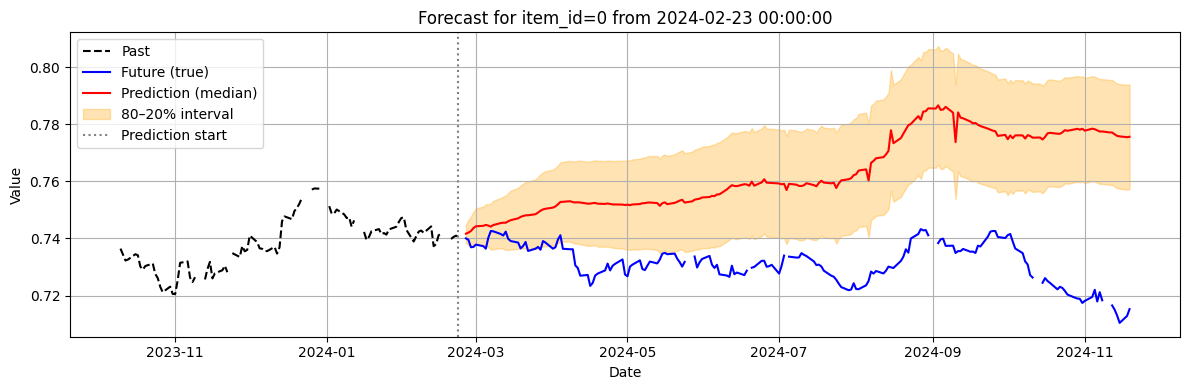

In [38]:
results["chronos-bolt-finetuned-full_PostprocessorMLE"].item_ids[0].plot_forecasts(300)

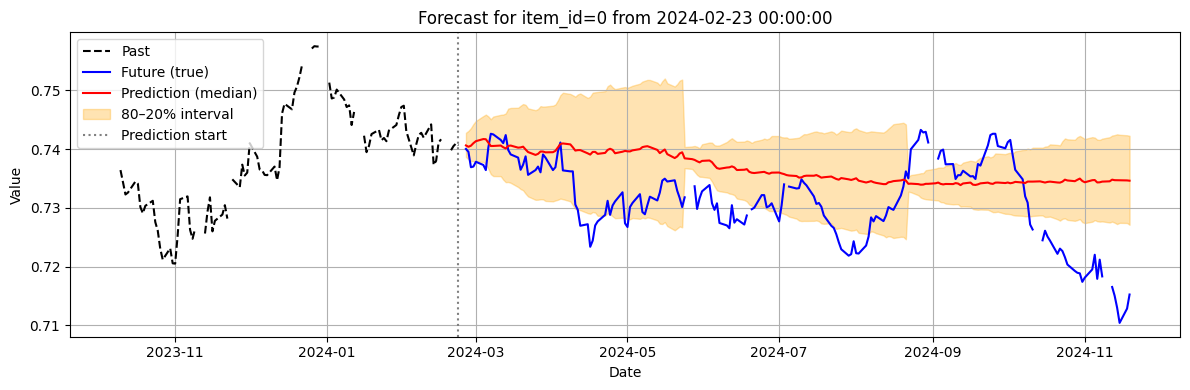

In [163]:
results["chronos-bolt-finetuned-full_Chronos"].item_ids[0].plot_forecasts(300)

Compute CRPS score: 100%|██████████| 7/7 [00:16<00:00,  2.30s/it]


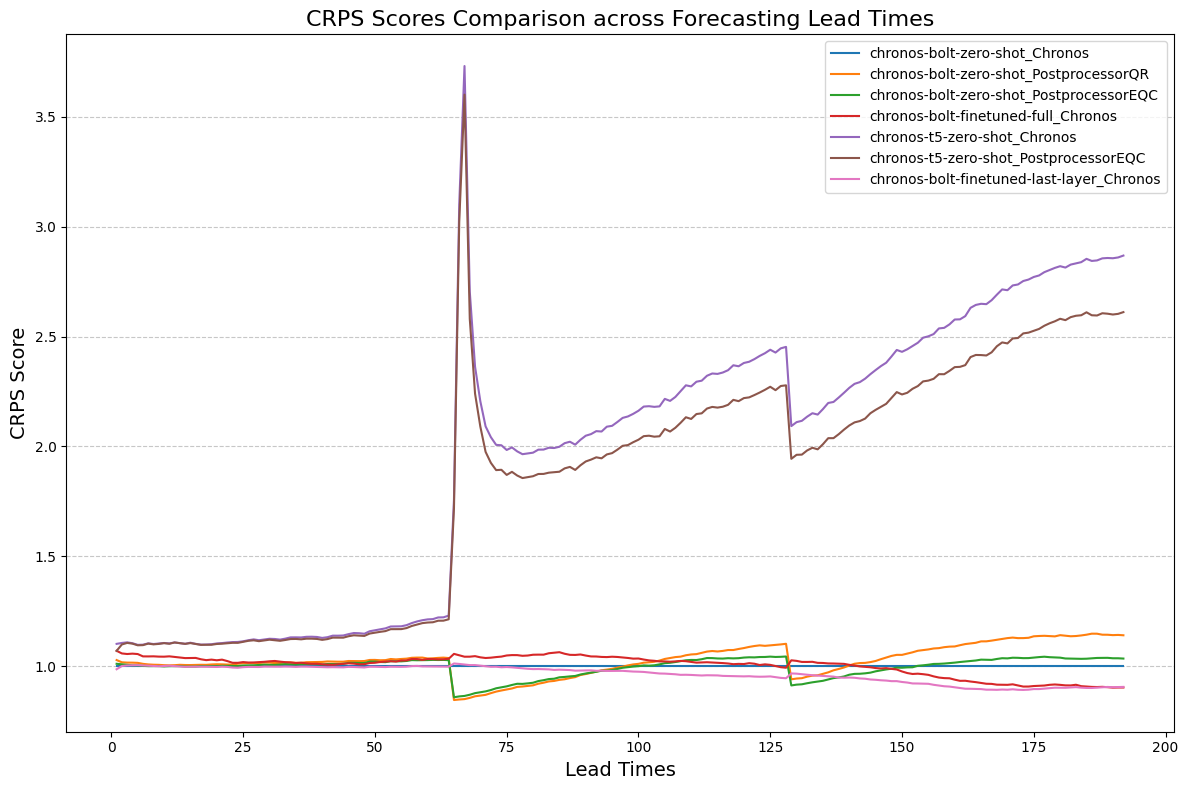

In [29]:
plot_crps_across_lead_times(results, 
                            selected_keys=["chronos-bolt-zero-shot_Chronos", 
                                            "chronos-bolt-zero-shot_PostprocessorQR",
                                            "chronos-bolt-zero-shot_PostprocessorEQC",
                                            "chronos-bolt-finetuned-last-layer_Chronos",
                                            "chronos-bolt-finetuned-full_Chronos",
                                            "chronos-t5-zero-shot_Chronos",
                                            "chronos-t5-zero-shot_PostprocessorEQC",
                                            # "chronos-bolt-finetuned-full_PostprocessorQR", # selected last 3 years for calibration -> bad results
                                            # "naive_rolling_RollingQuantilePredictor"
                                            ],
                            reference_predictions="chronos-bolt-zero-shot_Chronos")

Compute CRPS score: 100%|██████████| 5/5 [00:11<00:00,  2.30s/it]


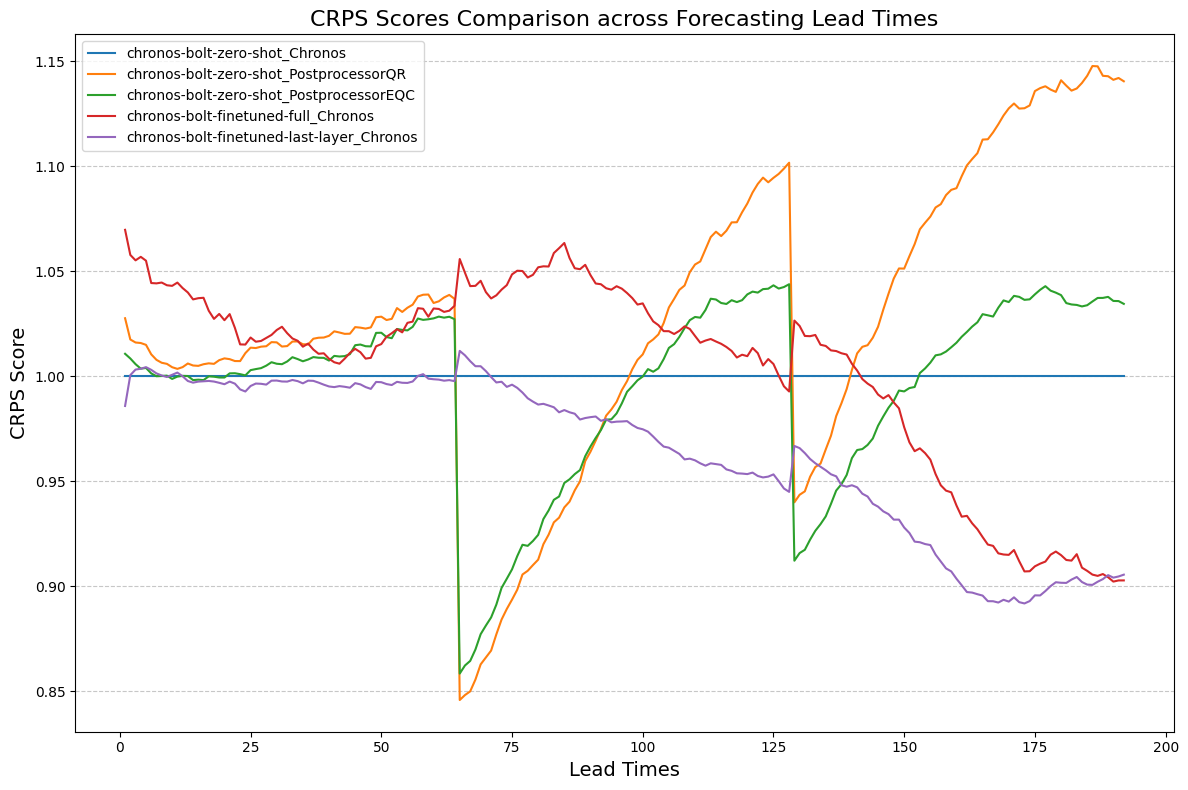

In [165]:
plot_crps_across_lead_times(results, 
                            selected_keys=["chronos-bolt-zero-shot_Chronos", 
                                            "chronos-bolt-zero-shot_PostprocessorQR",
                                            "chronos-bolt-zero-shot_PostprocessorEQC",
                                            "chronos-bolt-finetuned-last-layer_Chronos",
                                            "chronos-bolt-finetuned-full_Chronos",
                                            # "chronos-bolt-finetuned-full_PostprocessorQR", # selected last 3 years for calibration -> bad results
                                            # "naive_rolling_RollingQuantilePredictor"
                                            ],
                            reference_predictions="chronos-bolt-zero-shot_Chronos")

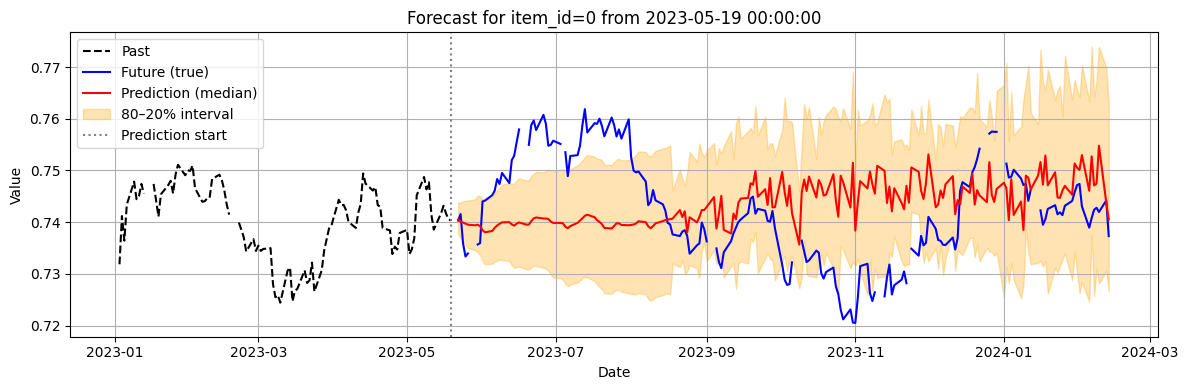

In [10]:
results["chronos-bolt-zero-shot-sampling_Chronos"].item_ids[0].plot_forecasts(start=100)

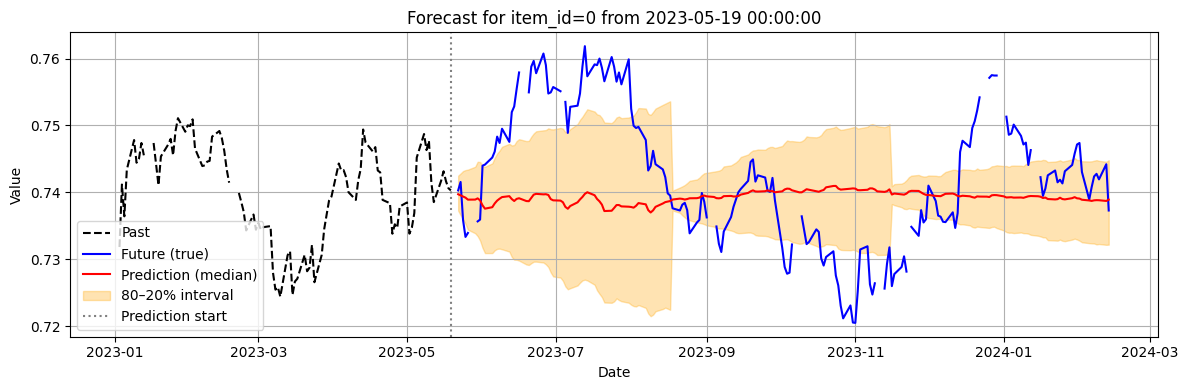

In [166]:
results["chronos-bolt-finetuned-last-layer_Chronos"].item_ids[0].plot_forecasts(start=100)

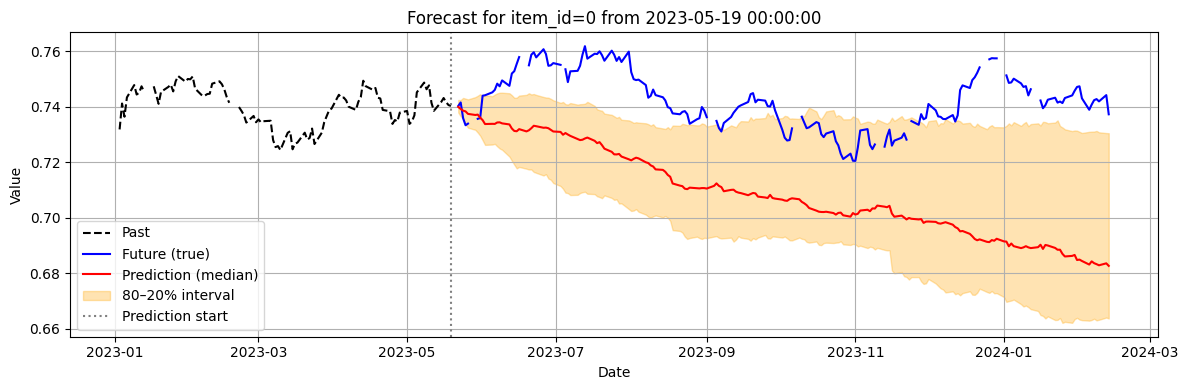

In [167]:
results["chronos-bolt-finetuned-full_PostprocessorEQC"].item_ids[0].plot_forecasts(start=100)

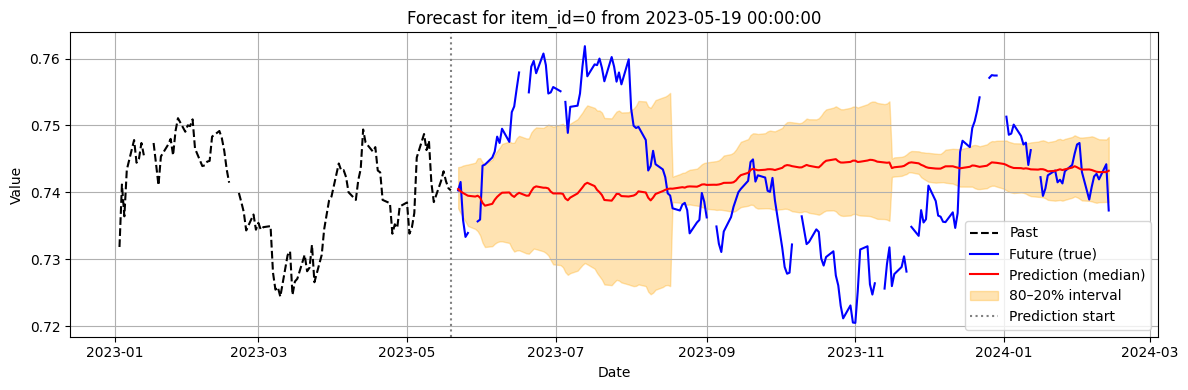

In [168]:
results["chronos-bolt-zero-shot_Chronos"].item_ids[0].plot_forecasts(start=100)

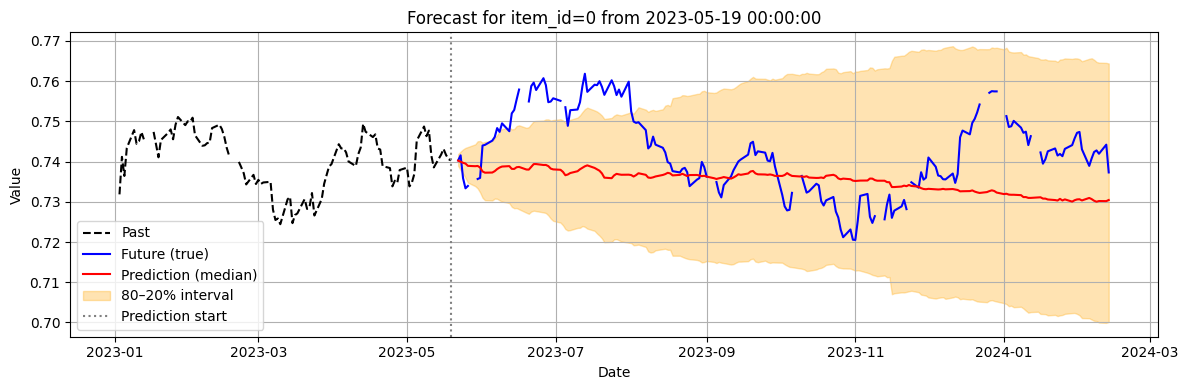

In [169]:
results["chronos-bolt-zero-shot_PostprocessorEQC"].item_ids[0].plot_forecasts(start=100)

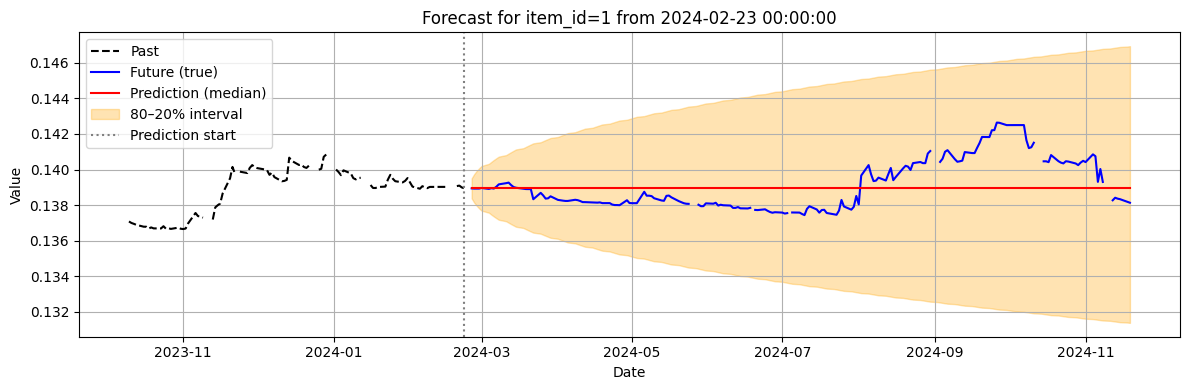

In [174]:
results["random_walk_RandomWalkBenchmark"].item_ids[1].plot_forecasts(start=300)

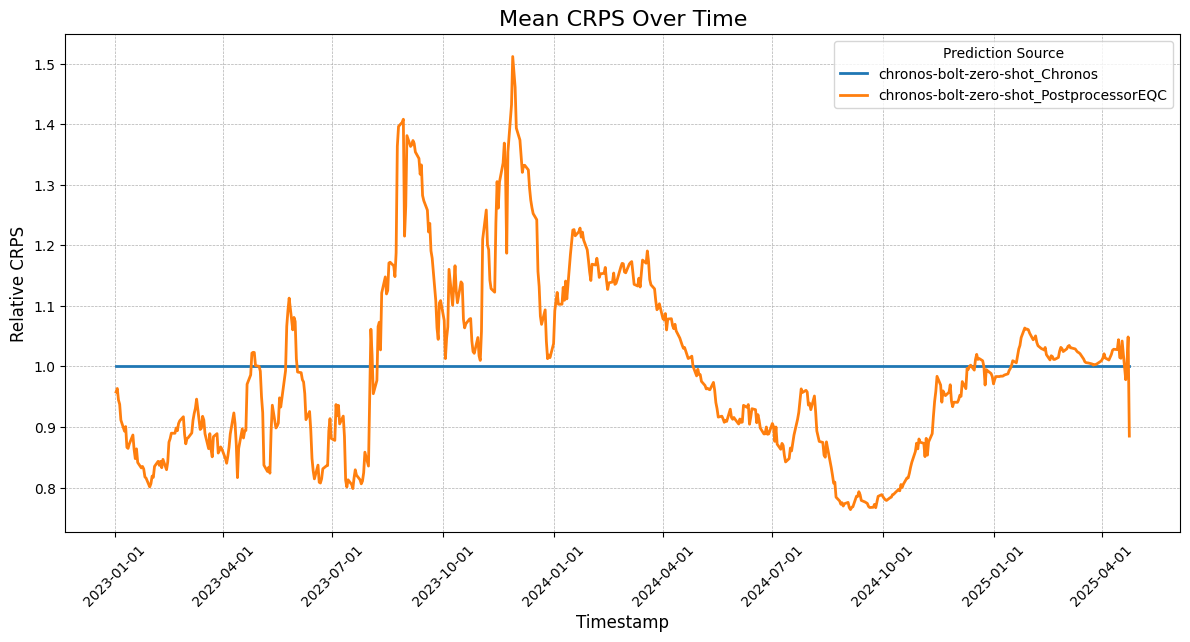

In [ ]:
# update offset not only once on a calibration dataset but continously update it
plot_crps(predictions=results, selected_keys=["chronos-bolt-zero-shot_PostprocessorEQC", "chronos-bolt-zero-shot_Chronos"], reference_predictions="chronos-bolt-zero-shot_Chronos")